# Flipkart Mobile Data Analysis

## Introduction
Flipkart is one of India's leading e-commerce platforms. This dataset contains information about mobile phones listed on Flipkart, including their price, ratings, brand, and specifications.

## Objective
The goal of this analysis is to:
- Understand price distribution of mobiles
- Identify top brands
- Analyze customer ratings
- Discover relationships between price and ratings

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading the Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/devsubhash/flipkart-mobiles-dataset/Flipkart_Mobiles.csv")
df.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990


In [3]:
brands_df = pd.read_csv("/kaggle/input/datasets/devsubhash/flipkart-mobiles-dataset/Flipkart_mobile_brands_scraped_data.csv")
brands_df.columns

Index(['Brand', 'Model', 'Color', 'Memory', 'Storage', 'Rating',
       'Selling Price', 'Original Price'],
      dtype='object')

In [4]:
df.shape

(3114, 8)

In [5]:
df.columns

Index(['Brand', 'Model', 'Color', 'Memory', 'Storage', 'Rating',
       'Selling Price', 'Original Price'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           3114 non-null   object 
 1   Model           3114 non-null   object 
 2   Color           3114 non-null   object 
 3   Memory          3071 non-null   object 
 4   Storage         3075 non-null   object 
 5   Rating          2970 non-null   float64
 6   Selling Price   3114 non-null   int64  
 7   Original Price  3114 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 194.8+ KB


In [7]:
df.describe()

,Rating,Selling Price,Original Price
count,2970.000000,3114.000000,3114.000000
mean,4.243098,26436.625562,28333.473025
std,0.271991,30066.892622,31525.599889
min,2.300000,1000.000000,1000.000000
25%,4.100000,9990.000000,10030.250000
50%,4.300000,15000.000000,16889.500000
75%,4.400000,28999.000000,31500.000000
max,5.000000,179900.000000,189999.000000


In [8]:
# Convert Price to Numeric
df['Selling Price'] = df['Selling Price'].astype(str)
df['Selling Price'] = df['Selling Price'].str.replace('₹', '')
df['Selling Price'] = df['Selling Price'].str.replace(',', '')
df['Selling Price'] = df['Selling Price'].astype(float)

df['Original Price'] = df['Original Price'].astype(str)
df['Original Price'] = df['Original Price'].str.replace('₹', '')
df['Original Price'] = df['Original Price'].str.replace(',', '')
df['Original Price'] = df['Original Price'].astype(float)

## Data Cleaning

In [9]:
# Convert Rating 
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [10]:
df.isnull().sum()

Brand               0
Model               0
Color               0
Memory             43
Storage            39
Rating            144
Selling Price       0
Original Price      0
dtype: int64

In [11]:
df.dropna(inplace = True)

## Feature Engineering

In [12]:
df["Discount"] = df["Original Price"] - df["Selling Price"]
df["Discount %"] = df["Discount"]/df["Original Price"] * 100

## Exploratory Data Analysis

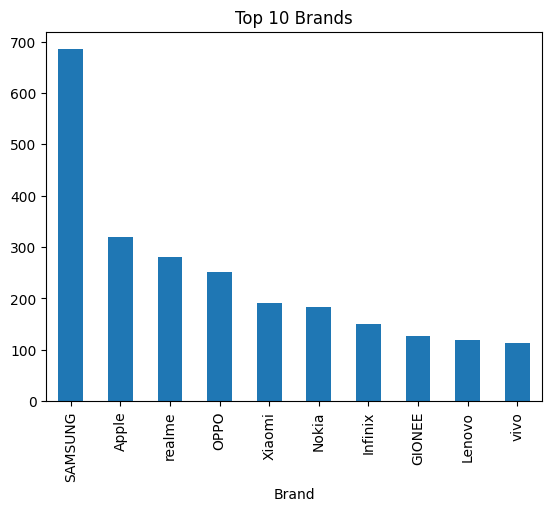

In [13]:
# Top Brands
df['Brand'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Brands")
plt.show()

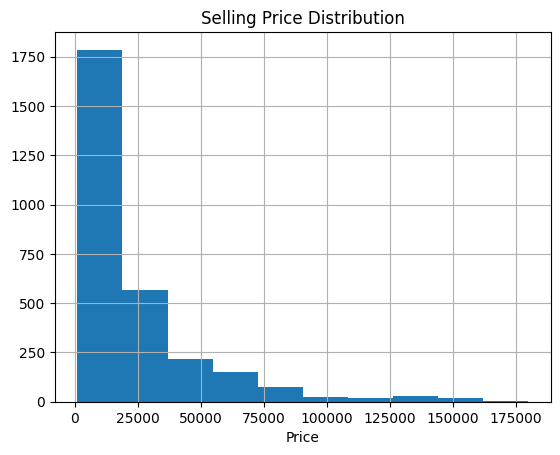

In [14]:
# Selling Price Distribution
df['Selling Price'].hist()
plt.title("Selling Price Distribution")
plt.xlabel("Price")
plt.show()

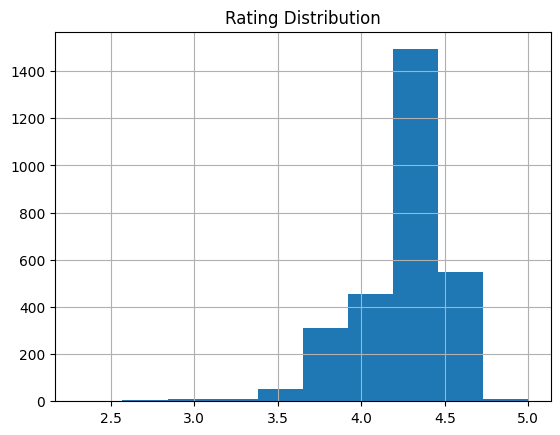

In [15]:
# Rating Distribution
df['Rating'].hist()
plt.title("Rating Distribution")
plt.show()

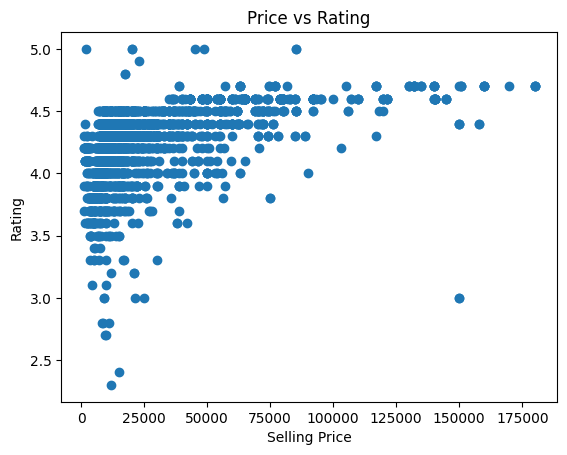

In [16]:
# Price VS Rating
plt.scatter(df['Selling Price'], df['Rating'])
plt.xlabel("Selling Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

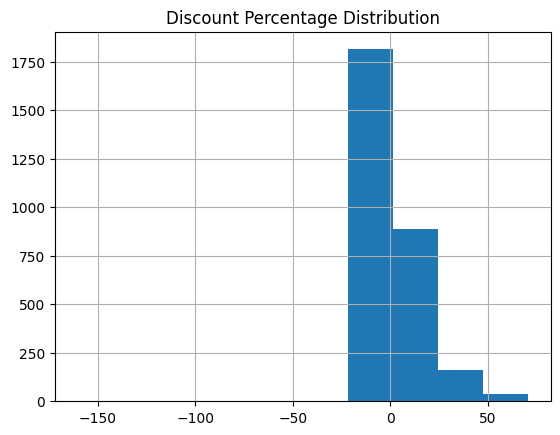

In [17]:
# Discount Distribution
df['Discount %'].hist()
plt.title("Discount Percentage Distribution")
plt.show()

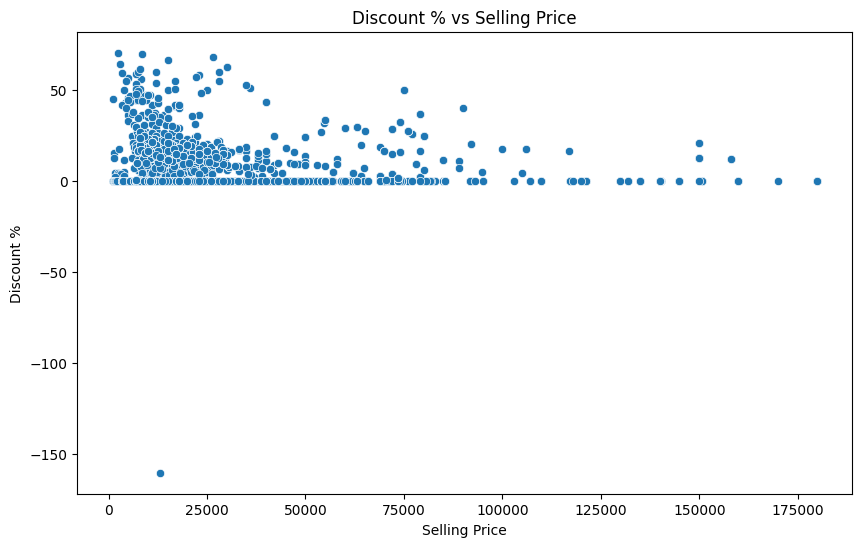

In [18]:
# Discount VS Price
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Selling Price', y='Discount %')
plt.title("Discount % vs Selling Price")
plt.show()

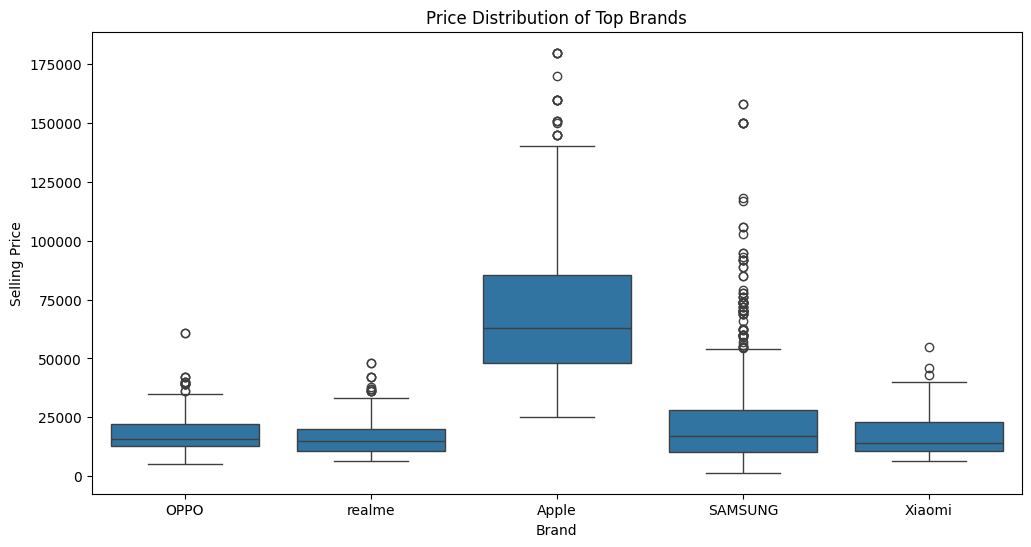

In [19]:
# Price by Brand (Box Plot)
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['Brand'].isin(df['Brand'].value_counts().index[:5])],
            x='Brand', y='Selling Price')
plt.title("Price Distribution of Top Brands")
plt.show()

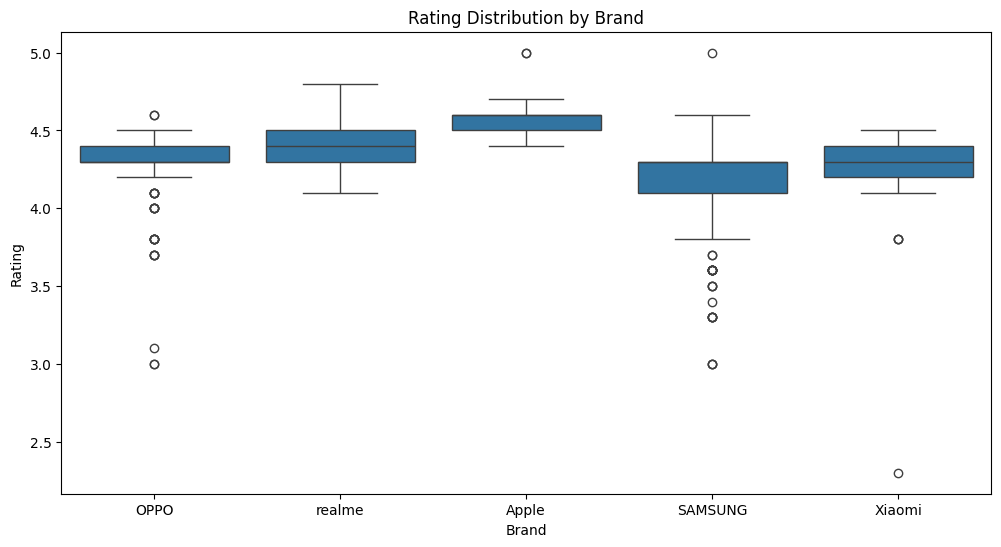

In [20]:
# Rating By Brand
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['Brand'].isin(df['Brand'].value_counts().index[:5])],
            x='Brand', y='Rating')
plt.title("Rating Distribution by Brand")
plt.show()

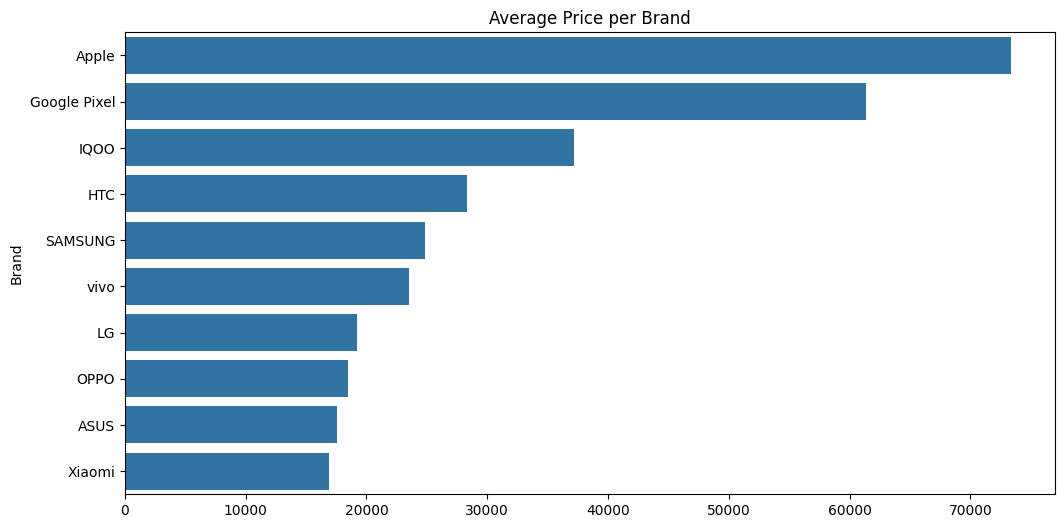

In [21]:
# Average Price Per Brand
avg_price = df.groupby('Brand')['Selling Price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_price.values, y=avg_price.index)
plt.title("Average Price per Brand")
plt.show()

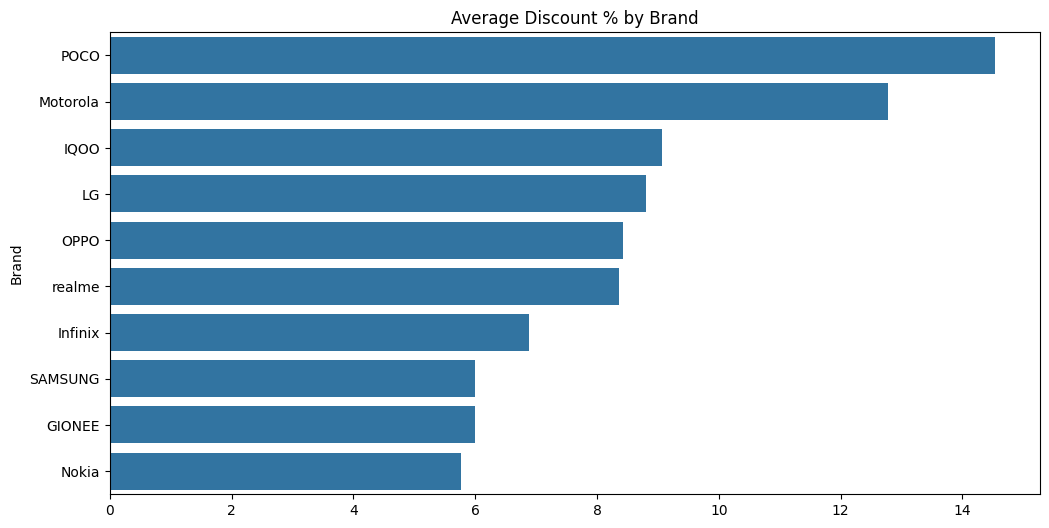

In [22]:
# Discount Percentage by Brand
avg_discount = df.groupby('Brand')['Discount %'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_discount.values, y=avg_discount.index)
plt.title("Average Discount % by Brand")
plt.show()

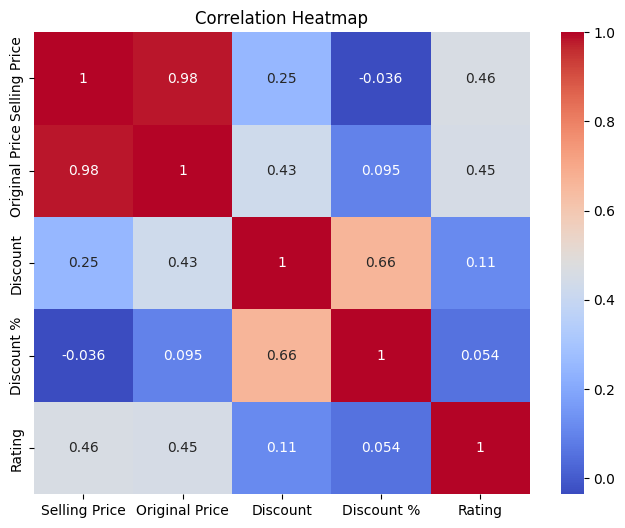

In [23]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Selling Price','Original Price','Discount','Discount %','Rating']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

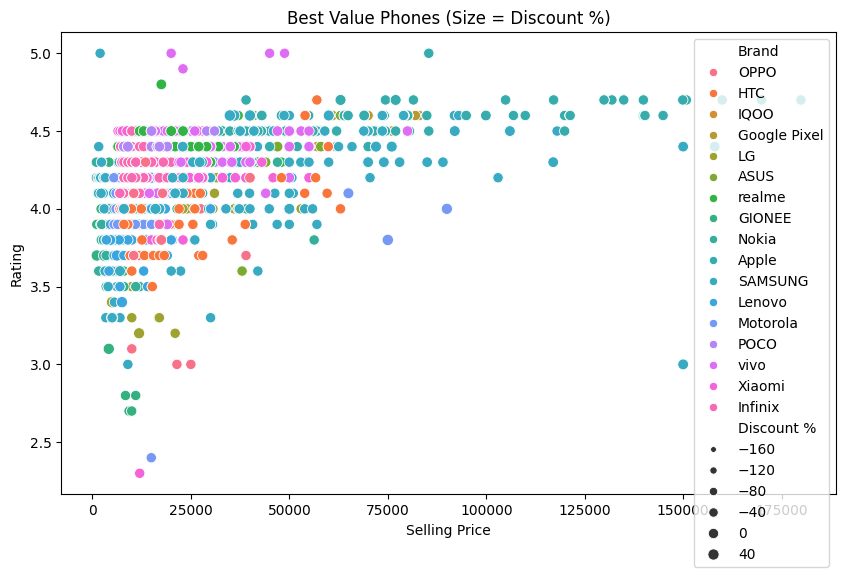

In [24]:
# Best Value Phones Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Selling Price', y='Rating', size='Discount %', hue='Brand')
plt.title("Best Value Phones (Size = Discount %)")
plt.show()

## Key Insights

- Most smartphones are available in the mid-range price category.
- Some brands dominate the mobile market listings.
- Discounts play a major role in attracting customers.
- Ratings mostly fall between 3.5 and 4.5.
- Expensive phones do not always have the highest ratings.
- Many budget phones offer good value for money.

## Conclusion

This analysis of Flipkart mobile data shows that price, discount, and ratings are key factors influencing customer choices. While premium phones exist, most users prefer affordable devices with good ratings.

Brands with competitive pricing and better discounts tend to perform better in the market.